<a href="https://colab.research.google.com/github/mfernandezzz/mediciones_sensores/blob/main/mediciones_sensores_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('/content/mediciones_sensores_limpio.xlsx')

In [3]:
df.head(10)

,fecha_hora,id_sensor,temperatura (°C),humedad,presión,rayos_uv
0,2023-01-01 14:11:00,SEN1,29.8,66.4,1017.5,MODERADO
1,2023-01-03 06:38:00,SEN2,33.6,42.0,1004.4,BAJO
2,2023-01-03 09:58:00,SEN5,29.8,65.3,1007.8,MODERADO
3,2023-01-03 17:05:00,SEN4,29.8,40.5,1013.1,MODERADO
4,2023-01-03 21:25:00,SEN4,29.8,86.8,997.8,NULO
5,2023-01-04 22:55:00,SEN3,29.8,52.6,1013.2,NULO
6,2023-01-05 04:06:00,SEN2,15.0,87.3,1000.6,NULO
7,2023-01-07 07:56:00,SEN2,29.8,45.6,1019.2,BAJO
8,2023-01-07 11:58:00,SEN5,32.5,62.5,991.6,ALTO
9,2023-01-08 04:08:00,SEN1,29.8,42.2,1014.4,NULO


Luego de realizada la limpieza de los datos, crear graficos que permitan mostrar informacion que pudiese ser relevante

**Grafico de Temperatura en funcion del tiempo**

<Axes: title={'center': 'Temperatura en funcion del tiempo'}, xlabel='Fecha y hora', ylabel='Temperatura'>

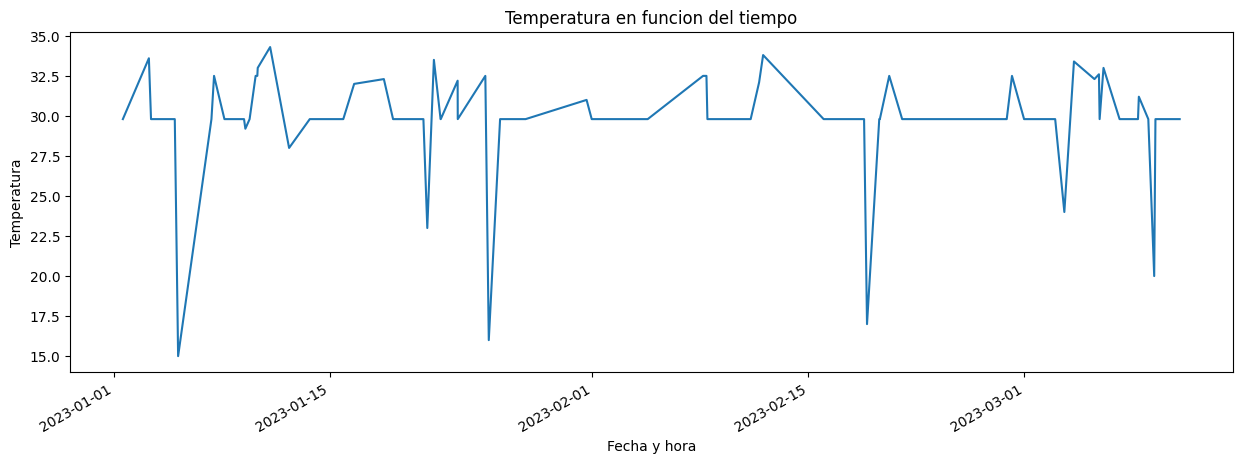

In [4]:
def line_plot_Temp():
  line_plot = df.plot(figsize=(15, 5), legend=False, x='fecha_hora', y='temperatura (°C)', kind='line')
  plt.title('Temperatura en funcion del tiempo')
  plt.xlabel('Fecha y hora')
  plt.ylabel('Temperatura')

  return line_plot

line_plot_Temp()

Obtener detalles de los valores anormalmente bajos de temperatura (menores a 20 ºC)

In [5]:
mask = df['temperatura (°C)'] < 20
anormal_values = df[mask]
anormal_values

,fecha_hora,id_sensor,temperatura (°C),humedad,presión,rayos_uv
6,2023-01-05 04:06:00,SEN2,15.0,87.3,1000.6,NULO
39,2023-01-25 07:13:00,SEN1,16.0,57.7,998.2,BAJO
67,2023-02-18 19:24:00,SEN4,17.0,42.5,1007.7,MODERADO


Asignar valor arbitrario de temperatura a los valores anormalmente bajos (opcional)

In [6]:
df['temperatura (°C)'] = df['temperatura (°C)'].apply(lambda x: 20 if x < 20 else x)
df.head(10)

,fecha_hora,id_sensor,temperatura (°C),humedad,presión,rayos_uv
0,2023-01-01 14:11:00,SEN1,29.8,66.4,1017.5,MODERADO
1,2023-01-03 06:38:00,SEN2,33.6,42.0,1004.4,BAJO
2,2023-01-03 09:58:00,SEN5,29.8,65.3,1007.8,MODERADO
3,2023-01-03 17:05:00,SEN4,29.8,40.5,1013.1,MODERADO
4,2023-01-03 21:25:00,SEN4,29.8,86.8,997.8,NULO
5,2023-01-04 22:55:00,SEN3,29.8,52.6,1013.2,NULO
6,2023-01-05 04:06:00,SEN2,20.0,87.3,1000.6,NULO
7,2023-01-07 07:56:00,SEN2,29.8,45.6,1019.2,BAJO
8,2023-01-07 11:58:00,SEN5,32.5,62.5,991.6,ALTO
9,2023-01-08 04:08:00,SEN1,29.8,42.2,1014.4,NULO


**Grafico de Temperatura en funcion del tiempo donde el nivel de rayos_uv es MODERADO - ALTO**

In [7]:
df['rayos_uv'].value_counts()

,count
rayos_uv,
NULO,38
MODERADO,24
BAJO,23
ALTO,15


In [8]:
#obtener una copia del dataframe con las mediciones donde el valor de la columna rayos_uv es MODERADO o ALTO
dfma = df[df['rayos_uv'].isin(['MODERADO', 'ALTO'])]
dfma.shape[0]

39

<Axes: title={'center': 'Temperatura en funcion del tiempo (nivel de rayos_uv MODERADO - ALTO)'}, xlabel='Fecha y hora', ylabel='Temperatura'>

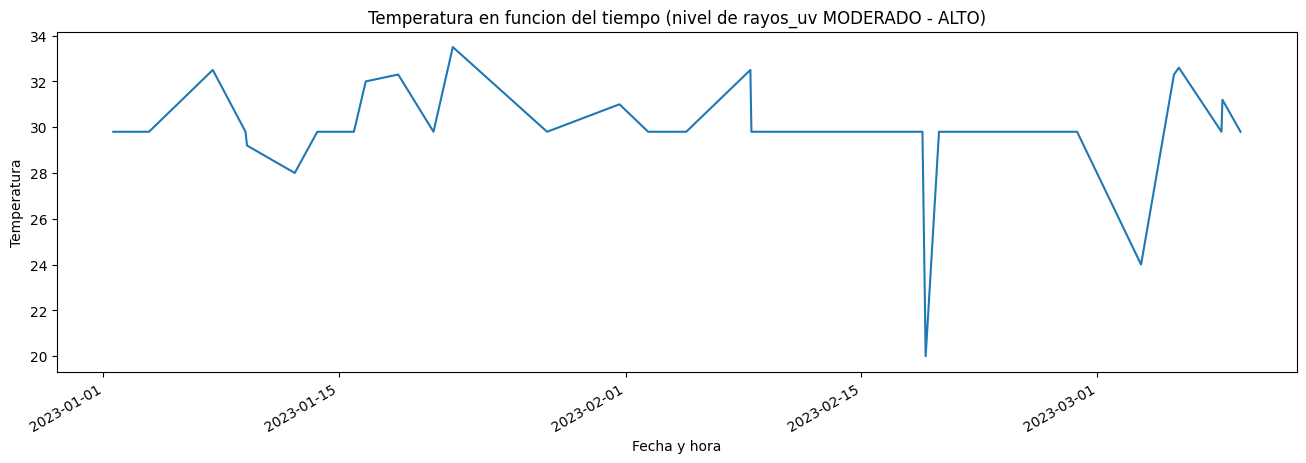

In [9]:
def line_plot_Temp_MA():
  line_plot = dfma.plot(figsize=(16, 5), legend=False, x='fecha_hora', y='temperatura (°C)', kind='line')
  plt.title('Temperatura en funcion del tiempo (nivel de rayos_uv MODERADO - ALTO)')
  plt.xlabel('Fecha y hora')
  plt.ylabel('Temperatura')

  return line_plot

line_plot_Temp_MA()

**Grafico de Temperatura media obtenida por cada sensor con los registros obtenidos durante Enero y Febrero**

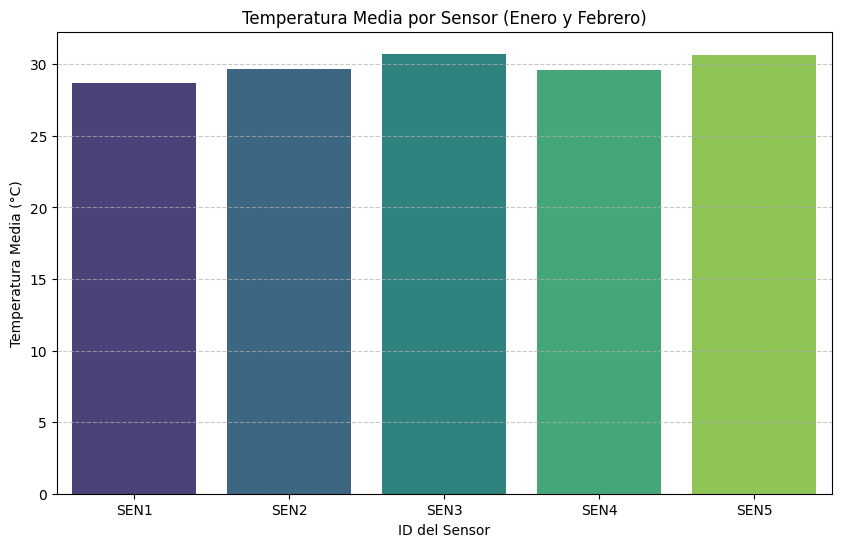

In [10]:
def bar_plot_Temp_JF():
  # change the column 'fecha_hora' to a datetime object
  df['fecha_hora'] = pd.to_datetime(df['fecha_hora'])

  # get the datetime objects from january and february
  df_enero_febrero = df[(df['fecha_hora'].dt.month == 1) | (df['fecha_hora'].dt.month == 2)]

  # specify the values for the x axis, the y axis (mean value of temperature) and reset the indexes
  media_temperatura_sensor = df_enero_febrero.groupby('id_sensor')['temperatura (°C)'].mean().reset_index()

  # create the plot
  plt.figure(figsize=(10, 6))
  # sns.set_style('whitegrid')
  # specify the source for the x and y axis values in the data variable
  sns.barplot(x='id_sensor', y='temperatura (°C)', data=media_temperatura_sensor, palette='viridis', hue='id_sensor')
  # plt.xticks(rotation=45
  plt.title('Temperatura Media por Sensor (Enero y Febrero)')
  plt.xlabel('ID del Sensor')
  plt.ylabel('Temperatura Media (°C)')
  plt.grid(axis='y', linestyle='--', alpha=0.7)

  return plt.show()

bar_plot_Temp_JF()

**Grafico de Temperatura media obtenida por cada sensor en los meses donde se obtuvieron mediciones**

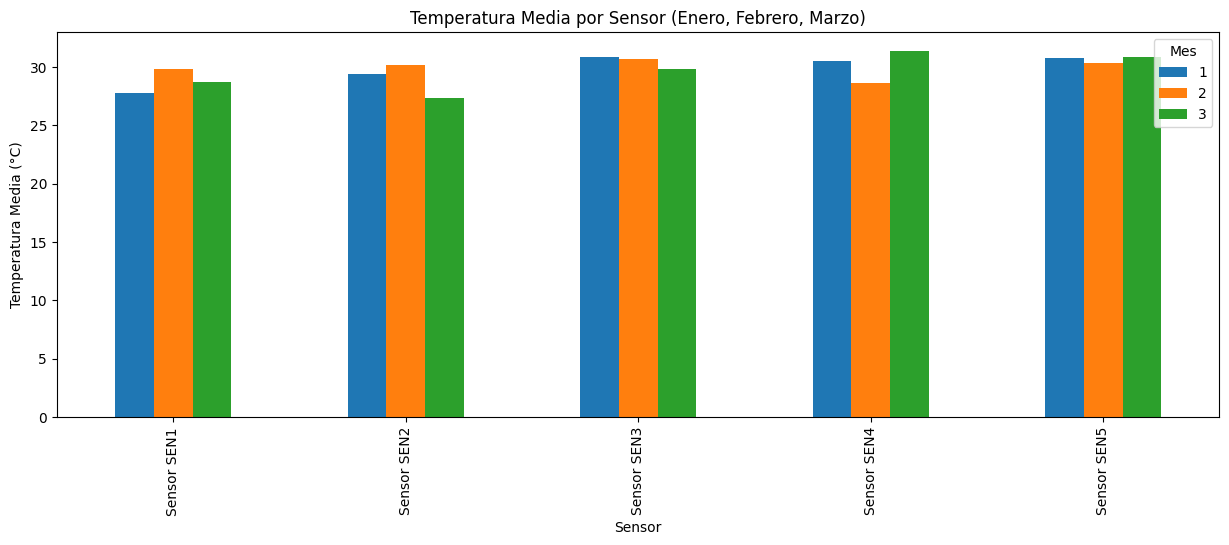

In [11]:
def bar_plot_temp_EF():
  dfc = df.copy()
  dfc.reset_index(inplace=True)

  dfc['mes'] = pd.DatetimeIndex(dfc['fecha_hora']).month
  dfc['sensor'] = dfc['id_sensor'].apply(lambda x: f'Sensor {x}')

  #df_enero_febrero = dfc[(dfc['fecha_hora'].dt.month == 1) | (dfc['fecha_hora'].dt.month == 2)]
  #dfc_grouped = df_enero_febrero.groupby('id_sensor')['temperatura (°C)'].mean().reset_index()

  dfc_grouped = dfc.groupby(['mes', 'sensor'])['temperatura (°C)'].mean()
  dfc_grouped = dfc_grouped.unstack(level=0)

  dfc_grouped.plot(kind='bar', figsize=(15, 5))
  plt.title('Temperatura Media por Sensor (Enero, Febrero, Marzo)')
  plt.xlabel('Sensor')
  plt.ylabel('Temperatura Media (°C)')
  plt.legend(title='Mes')

  return plt.show()

bar_plot_temp_EF()

**Grafico de Temperatura en funcion del tiempo solo de las mediciones del sensor con mas cantidad de registros.**

In [12]:
df['id_sensor'].value_counts()

,count
id_sensor,
SEN5,24
SEN2,21
SEN1,19
SEN3,19
SEN4,17


In [13]:
df_sen5 = df[df['id_sensor'].str.contains('SEN5')]
df_sen5.shape[0]

24

<Axes: title={'center': 'Temperatura en funcion del tiempo (SEN5)'}, xlabel='Fecha y hora', ylabel='Temperatura ºC'>

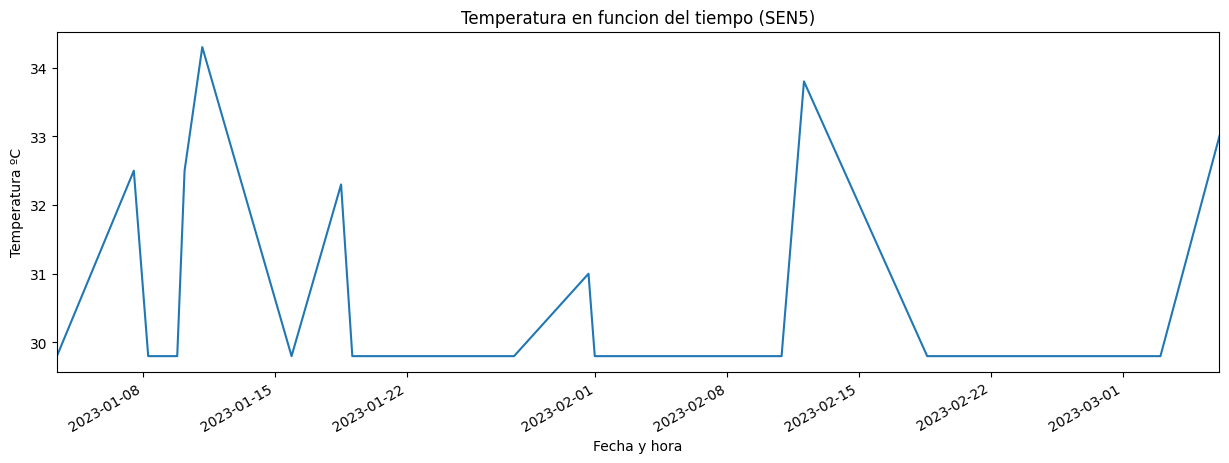

In [14]:
def draw_line_plot_Temp_sen5():
  line_plot = df_sen5.plot(figsize=(15, 5), legend=False, x='fecha_hora', y='temperatura (°C)', kind='line')
  plt.title('Temperatura en funcion del tiempo (SEN5)')
  plt.xlabel('Fecha y hora')
  plt.ylabel('Temperatura ºC')
  plt.xlim('2023-01-03 09:58:00', '2023-03-06 03:09:00')
  #plt.ylim(0, 40)

  return line_plot

draw_line_plot_Temp_sen5()

**Grafico de Humedad en funcion del tiempo solo de las mediciones del sensor con mas cantidad de registros.**

<Axes: title={'center': 'Humedad en funcion del tiempo (SEN5)'}, xlabel='Fecha y hora', ylabel='Humedad'>

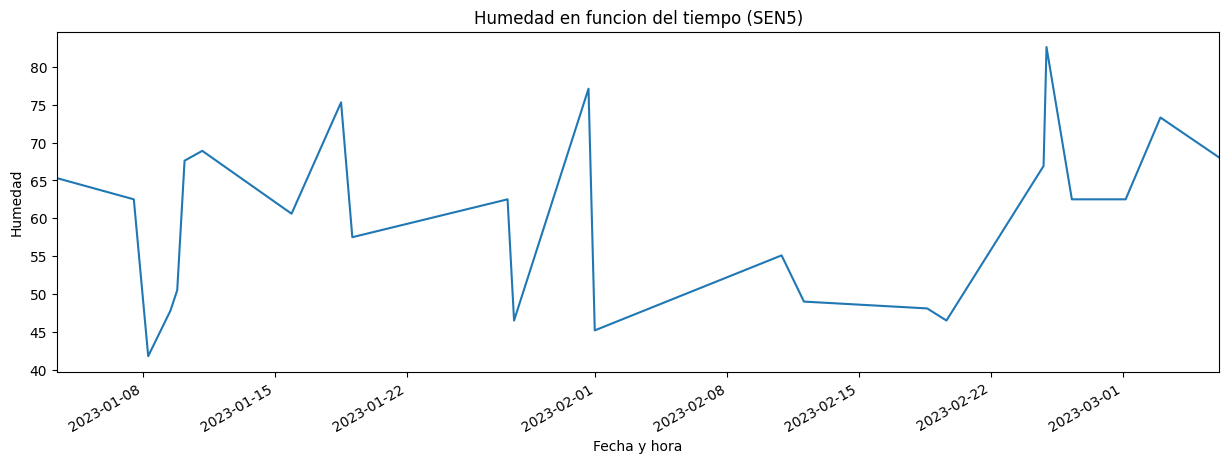

In [15]:
def draw_line_plot_hum_sen5():
  line_plot = df_sen5.plot(figsize=(15, 5), legend=False, x='fecha_hora', y='humedad', kind='line')
  plt.title('Humedad en funcion del tiempo (SEN5)')
  plt.xlabel('Fecha y hora')
  plt.ylabel('Humedad')
  plt.xlim('2023-01-03 09:58:00', '2023-03-06 03:09:00')
  #plt.ylim(0, 100)

  return line_plot

draw_line_plot_hum_sen5()

**Grafico de Temperatura en funcion del tiempo con una linea por cada sensor solo de las mediciones obtenidas durante enero.**

In [16]:
df_enero = df[df['fecha_hora'].dt.month == 1]
df_enero.shape[0]

48

In [17]:
df_enero.tail(10)

,fecha_hora,id_sensor,temperatura (°C),humedad,presión,rayos_uv
38,2023-01-25 01:51:00,SEN3,32.5,65.3,1011.8,NULO
39,2023-01-25 07:13:00,SEN1,20.0,57.7,998.2,BAJO
40,2023-01-26 00:48:00,SEN1,29.8,72.9,1015.7,NULO
41,2023-01-26 07:01:00,SEN1,29.8,83.9,991.6,BAJO
42,2023-01-26 07:14:00,SEN4,29.8,42.1,1017.8,BAJO
43,2023-01-26 07:43:00,SEN1,29.8,80.4,1002.1,BAJO
44,2023-01-27 08:10:00,SEN5,29.8,62.5,1011.2,ALTO
45,2023-01-27 16:27:00,SEN5,29.8,46.5,996.7,BAJO
46,2023-01-31 15:18:00,SEN5,31.0,77.1,1018.2,MODERADO
47,2023-01-31 23:17:00,SEN5,29.8,45.2,996.7,NULO


In [18]:
df_enero.set_index('fecha_hora', inplace=True)
df_enero.head()


,id_sensor,temperatura (°C),humedad,presión,rayos_uv
fecha_hora,,,,,
2023-01-01 14:11:00,SEN1,29.8,66.4,1017.5,MODERADO
2023-01-03 06:38:00,SEN2,33.6,42.0,1004.4,BAJO
2023-01-03 09:58:00,SEN5,29.8,65.3,1007.8,MODERADO
2023-01-03 17:05:00,SEN4,29.8,40.5,1013.1,MODERADO
2023-01-03 21:25:00,SEN4,29.8,86.8,997.8,NULO


In [19]:
#create a new dataframe with the relevant data for ploting and assign a index
temp_jan = pd.DataFrame(index=df_enero.index)
temp_jan.head()

""
fecha_hora
2023-01-01 14:11:00
2023-01-03 06:38:00
2023-01-03 09:58:00
2023-01-03 17:05:00
2023-01-03 21:25:00


In [20]:
# crear una columna for cada sensor
temp_jan['SEN1'] = df_enero['temperatura (°C)'][df_enero['id_sensor'].str.contains('SEN1')]
temp_jan['SEN2'] = df_enero['temperatura (°C)'][df_enero['id_sensor'].str.contains('SEN2')]
temp_jan['SEN3'] = df_enero['temperatura (°C)'][df_enero['id_sensor'].str.contains('SEN3')]
temp_jan['SEN4'] = df_enero['temperatura (°C)'][df_enero['id_sensor'].str.contains('SEN4')]
temp_jan['SEN5'] = df_enero['temperatura (°C)'][df_enero['id_sensor'].str.contains('SEN5')]
temp_jan.head(10)

,SEN1,SEN2,SEN3,SEN4,SEN5
fecha_hora,,,,,
2023-01-01 14:11:00,29.8,NaN,NaN,NaN,NaN
2023-01-03 06:38:00,NaN,33.6,NaN,NaN,NaN
2023-01-03 09:58:00,NaN,NaN,NaN,NaN,29.8
2023-01-03 17:05:00,NaN,NaN,NaN,29.8,NaN
2023-01-03 21:25:00,NaN,NaN,NaN,29.8,NaN
2023-01-04 22:55:00,NaN,NaN,29.8,NaN,NaN
2023-01-05 04:06:00,NaN,20.0,NaN,NaN,NaN
2023-01-07 07:56:00,NaN,29.8,NaN,NaN,NaN
2023-01-07 11:58:00,NaN,NaN,NaN,NaN,32.5


<Axes: xlabel='fecha_hora'>

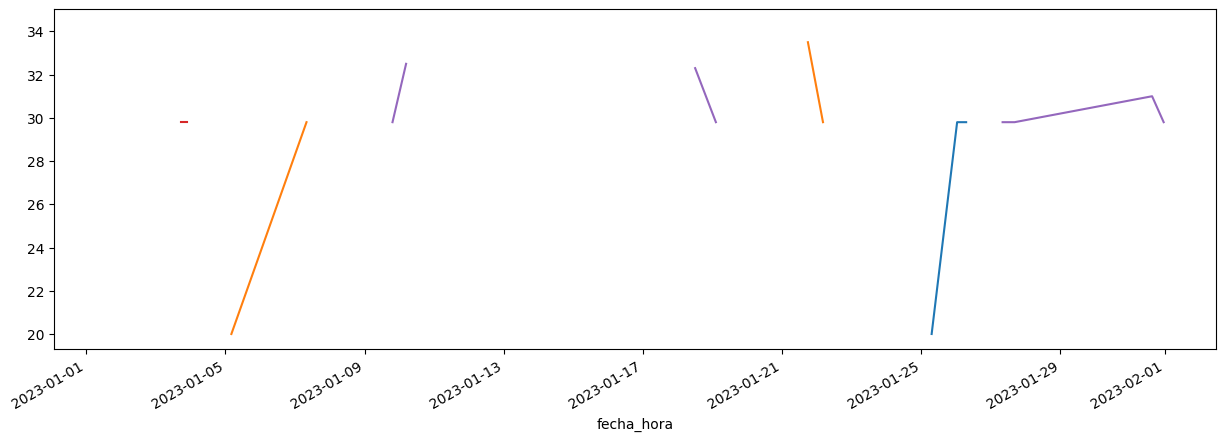

In [21]:
temp_jan.plot(figsize=(15, 5), legend=False,)

In [22]:
temp_sen1 = np.array(temp_jan['SEN1'])
temp_sen1_clean = temp_jan[~np.isnan(temp_sen1)]
len(temp_sen1_clean)

8

In [23]:
temp_sen2 = np.array(temp_jan['SEN2'])
temp_sen2_clean = temp_jan[~np.isnan(temp_sen2)]
len(temp_sen2_clean)

11

In [24]:
temp_sen3 = np.array(temp_jan['SEN3'])
temp_sen3_clean = temp_jan[~np.isnan(temp_sen3)]
len(temp_sen3_clean)

8

In [25]:
temp_sen4 = np.array(temp_jan['SEN4'])
temp_sen4_clean = temp_jan[~np.isnan(temp_sen4)]
len(temp_sen4_clean)

7

In [26]:
temp_sen5 = np.array(temp_jan['SEN5'])
temp_sen5_clean = temp_jan[~np.isnan(temp_sen5)]
len(temp_sen5_clean)

14

Completar los valores nan con el valor valido inmediato

In [27]:
temp_jan['SEN1'] = temp_jan['SEN1'].ffill()
temp_jan.head(15)

,SEN1,SEN2,SEN3,SEN4,SEN5
fecha_hora,,,,,
2023-01-01 14:11:00,29.8,NaN,NaN,NaN,NaN
2023-01-03 06:38:00,29.8,33.6,NaN,NaN,NaN
2023-01-03 09:58:00,29.8,NaN,NaN,NaN,29.8
2023-01-03 17:05:00,29.8,NaN,NaN,29.8,NaN
2023-01-03 21:25:00,29.8,NaN,NaN,29.8,NaN
2023-01-04 22:55:00,29.8,NaN,29.8,NaN,NaN
2023-01-05 04:06:00,29.8,20.0,NaN,NaN,NaN
2023-01-07 07:56:00,29.8,29.8,NaN,NaN,NaN
2023-01-07 11:58:00,29.8,NaN,NaN,NaN,32.5


In [28]:
temp_jan['SEN2'] = temp_jan['SEN2'].ffill()
temp_jan['SEN2'] = temp_jan['SEN2'].bfill()
temp_jan.head(15)

,SEN1,SEN2,SEN3,SEN4,SEN5
fecha_hora,,,,,
2023-01-01 14:11:00,29.8,33.6,NaN,NaN,NaN
2023-01-03 06:38:00,29.8,33.6,NaN,NaN,NaN
2023-01-03 09:58:00,29.8,33.6,NaN,NaN,29.8
2023-01-03 17:05:00,29.8,33.6,NaN,29.8,NaN
2023-01-03 21:25:00,29.8,33.6,NaN,29.8,NaN
2023-01-04 22:55:00,29.8,33.6,29.8,NaN,NaN
2023-01-05 04:06:00,29.8,20.0,NaN,NaN,NaN
2023-01-07 07:56:00,29.8,29.8,NaN,NaN,NaN
2023-01-07 11:58:00,29.8,29.8,NaN,NaN,32.5


In [29]:
temp_jan['SEN3'] = temp_jan['SEN3'].ffill()
temp_jan['SEN3'] = temp_jan['SEN3'].bfill()
temp_jan.head(15)

,SEN1,SEN2,SEN3,SEN4,SEN5
fecha_hora,,,,,
2023-01-01 14:11:00,29.8,33.6,29.8,NaN,NaN
2023-01-03 06:38:00,29.8,33.6,29.8,NaN,NaN
2023-01-03 09:58:00,29.8,33.6,29.8,NaN,29.8
2023-01-03 17:05:00,29.8,33.6,29.8,29.8,NaN
2023-01-03 21:25:00,29.8,33.6,29.8,29.8,NaN
2023-01-04 22:55:00,29.8,33.6,29.8,NaN,NaN
2023-01-05 04:06:00,29.8,20.0,29.8,NaN,NaN
2023-01-07 07:56:00,29.8,29.8,29.8,NaN,NaN
2023-01-07 11:58:00,29.8,29.8,29.8,NaN,32.5


In [30]:
temp_jan['SEN4'] = temp_jan['SEN4'].ffill()
temp_jan['SEN4'] = temp_jan['SEN4'].bfill()
temp_jan.head(15)

,SEN1,SEN2,SEN3,SEN4,SEN5
fecha_hora,,,,,
2023-01-01 14:11:00,29.8,33.6,29.8,29.8,NaN
2023-01-03 06:38:00,29.8,33.6,29.8,29.8,NaN
2023-01-03 09:58:00,29.8,33.6,29.8,29.8,29.8
2023-01-03 17:05:00,29.8,33.6,29.8,29.8,NaN
2023-01-03 21:25:00,29.8,33.6,29.8,29.8,NaN
2023-01-04 22:55:00,29.8,33.6,29.8,29.8,NaN
2023-01-05 04:06:00,29.8,20.0,29.8,29.8,NaN
2023-01-07 07:56:00,29.8,29.8,29.8,29.8,NaN
2023-01-07 11:58:00,29.8,29.8,29.8,29.8,32.5


In [31]:
temp_jan['SEN5'] = temp_jan['SEN5'].ffill()
temp_jan['SEN5'] = temp_jan['SEN5'].bfill()
temp_jan.head(15)

,SEN1,SEN2,SEN3,SEN4,SEN5
fecha_hora,,,,,
2023-01-01 14:11:00,29.8,33.6,29.8,29.8,29.8
2023-01-03 06:38:00,29.8,33.6,29.8,29.8,29.8
2023-01-03 09:58:00,29.8,33.6,29.8,29.8,29.8
2023-01-03 17:05:00,29.8,33.6,29.8,29.8,29.8
2023-01-03 21:25:00,29.8,33.6,29.8,29.8,29.8
2023-01-04 22:55:00,29.8,33.6,29.8,29.8,29.8
2023-01-05 04:06:00,29.8,20.0,29.8,29.8,29.8
2023-01-07 07:56:00,29.8,29.8,29.8,29.8,29.8
2023-01-07 11:58:00,29.8,29.8,29.8,29.8,32.5


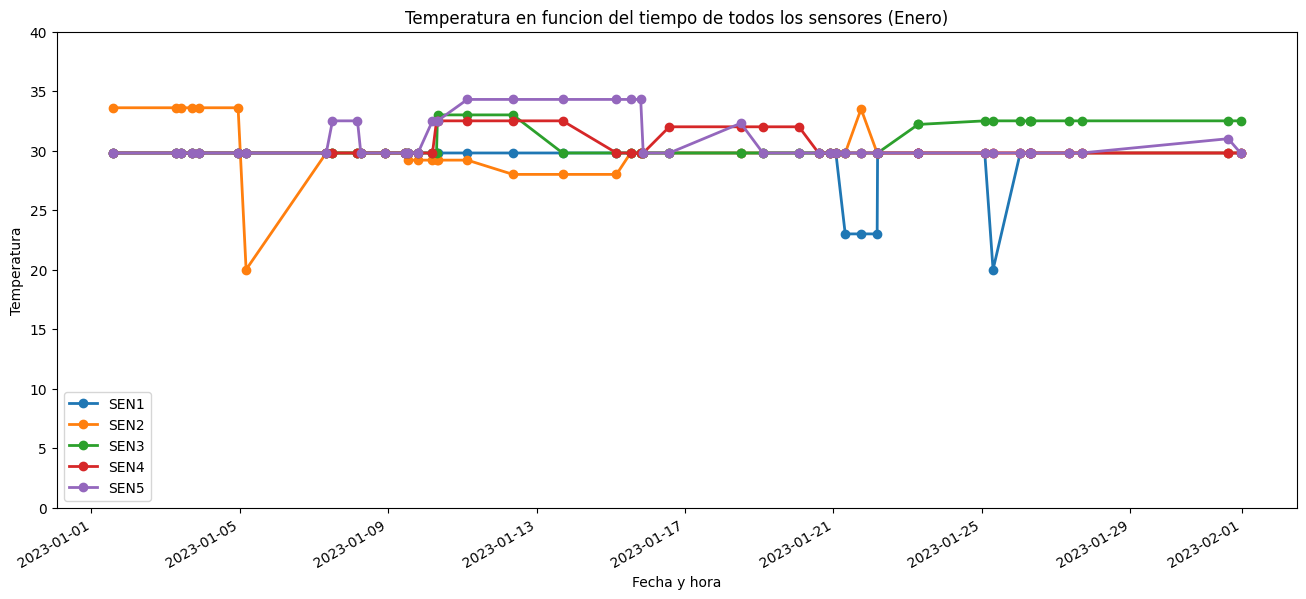

In [32]:
def line_plot_Temp_jan():
  temp_jan.plot(figsize=(16, 7), legend=True, marker='o', linewidth=2.0)
  plt.title('Temperatura en funcion del tiempo de todos los sensores (Enero)')
  plt.xlabel('Fecha y hora')
  plt.ylabel('Temperatura')
  plt.ylim(0, 40)

  return plt.show()

line_plot_Temp_jan()

**Grafico de Humedad en funcion del tiempo con una linea por cada sensor solo de las mediciones obtenidas durante enero.**

In [33]:
hum_jan = pd.DataFrame(index=df_enero.index)
hum_jan['SEN1'] = df_enero['humedad'][df_enero['id_sensor'].str.contains('SEN1')]
hum_jan['SEN2'] = df_enero['humedad'][df_enero['id_sensor'].str.contains('SEN2')]
hum_jan['SEN3'] = df_enero['humedad'][df_enero['id_sensor'].str.contains('SEN3')]
hum_jan['SEN4'] = df_enero['humedad'][df_enero['id_sensor'].str.contains('SEN4')]
hum_jan['SEN5'] = df_enero['humedad'][df_enero['id_sensor'].str.contains('SEN5')]
hum_jan.head(15)

,SEN1,SEN2,SEN3,SEN4,SEN5
fecha_hora,,,,,
2023-01-01 14:11:00,66.4,NaN,NaN,NaN,NaN
2023-01-03 06:38:00,NaN,42.0,NaN,NaN,NaN
2023-01-03 09:58:00,NaN,NaN,NaN,NaN,65.3
2023-01-03 17:05:00,NaN,NaN,NaN,40.5,NaN
2023-01-03 21:25:00,NaN,NaN,NaN,86.8,NaN
2023-01-04 22:55:00,NaN,NaN,52.6,NaN,NaN
2023-01-05 04:06:00,NaN,87.3,NaN,NaN,NaN
2023-01-07 07:56:00,NaN,45.6,NaN,NaN,NaN
2023-01-07 11:58:00,NaN,NaN,NaN,NaN,62.5


In [34]:
hum_jan['SEN1'] = hum_jan['SEN1'].ffill()
hum_jan.head(15)

,SEN1,SEN2,SEN3,SEN4,SEN5
fecha_hora,,,,,
2023-01-01 14:11:00,66.4,NaN,NaN,NaN,NaN
2023-01-03 06:38:00,66.4,42.0,NaN,NaN,NaN
2023-01-03 09:58:00,66.4,NaN,NaN,NaN,65.3
2023-01-03 17:05:00,66.4,NaN,NaN,40.5,NaN
2023-01-03 21:25:00,66.4,NaN,NaN,86.8,NaN
2023-01-04 22:55:00,66.4,NaN,52.6,NaN,NaN
2023-01-05 04:06:00,66.4,87.3,NaN,NaN,NaN
2023-01-07 07:56:00,66.4,45.6,NaN,NaN,NaN
2023-01-07 11:58:00,66.4,NaN,NaN,NaN,62.5


In [35]:
hum_jan['SEN2'] = hum_jan['SEN2'].ffill()
hum_jan['SEN2'] = hum_jan['SEN2'].bfill()
hum_jan.head(15)

,SEN1,SEN2,SEN3,SEN4,SEN5
fecha_hora,,,,,
2023-01-01 14:11:00,66.4,42.0,NaN,NaN,NaN
2023-01-03 06:38:00,66.4,42.0,NaN,NaN,NaN
2023-01-03 09:58:00,66.4,42.0,NaN,NaN,65.3
2023-01-03 17:05:00,66.4,42.0,NaN,40.5,NaN
2023-01-03 21:25:00,66.4,42.0,NaN,86.8,NaN
2023-01-04 22:55:00,66.4,42.0,52.6,NaN,NaN
2023-01-05 04:06:00,66.4,87.3,NaN,NaN,NaN
2023-01-07 07:56:00,66.4,45.6,NaN,NaN,NaN
2023-01-07 11:58:00,66.4,45.6,NaN,NaN,62.5


In [36]:
hum_jan['SEN3'] = hum_jan['SEN3'].ffill()
hum_jan['SEN3'] = hum_jan['SEN3'].bfill()
hum_jan.head(15)

,SEN1,SEN2,SEN3,SEN4,SEN5
fecha_hora,,,,,
2023-01-01 14:11:00,66.4,42.0,52.6,NaN,NaN
2023-01-03 06:38:00,66.4,42.0,52.6,NaN,NaN
2023-01-03 09:58:00,66.4,42.0,52.6,NaN,65.3
2023-01-03 17:05:00,66.4,42.0,52.6,40.5,NaN
2023-01-03 21:25:00,66.4,42.0,52.6,86.8,NaN
2023-01-04 22:55:00,66.4,42.0,52.6,NaN,NaN
2023-01-05 04:06:00,66.4,87.3,52.6,NaN,NaN
2023-01-07 07:56:00,66.4,45.6,52.6,NaN,NaN
2023-01-07 11:58:00,66.4,45.6,52.6,NaN,62.5


In [37]:
hum_jan['SEN4'] = hum_jan['SEN4'].ffill()
hum_jan['SEN4'] = hum_jan['SEN4'].bfill()
hum_jan.head(15)

,SEN1,SEN2,SEN3,SEN4,SEN5
fecha_hora,,,,,
2023-01-01 14:11:00,66.4,42.0,52.6,40.5,NaN
2023-01-03 06:38:00,66.4,42.0,52.6,40.5,NaN
2023-01-03 09:58:00,66.4,42.0,52.6,40.5,65.3
2023-01-03 17:05:00,66.4,42.0,52.6,40.5,NaN
2023-01-03 21:25:00,66.4,42.0,52.6,86.8,NaN
2023-01-04 22:55:00,66.4,42.0,52.6,86.8,NaN
2023-01-05 04:06:00,66.4,87.3,52.6,86.8,NaN
2023-01-07 07:56:00,66.4,45.6,52.6,86.8,NaN
2023-01-07 11:58:00,66.4,45.6,52.6,86.8,62.5


In [38]:
hum_jan['SEN5'] = hum_jan['SEN5'].ffill()
hum_jan['SEN5'] = hum_jan['SEN5'].bfill()
hum_jan.head(15)

,SEN1,SEN2,SEN3,SEN4,SEN5
fecha_hora,,,,,
2023-01-01 14:11:00,66.4,42.0,52.6,40.5,65.3
2023-01-03 06:38:00,66.4,42.0,52.6,40.5,65.3
2023-01-03 09:58:00,66.4,42.0,52.6,40.5,65.3
2023-01-03 17:05:00,66.4,42.0,52.6,40.5,65.3
2023-01-03 21:25:00,66.4,42.0,52.6,86.8,65.3
2023-01-04 22:55:00,66.4,42.0,52.6,86.8,65.3
2023-01-05 04:06:00,66.4,87.3,52.6,86.8,65.3
2023-01-07 07:56:00,66.4,45.6,52.6,86.8,65.3
2023-01-07 11:58:00,66.4,45.6,52.6,86.8,62.5


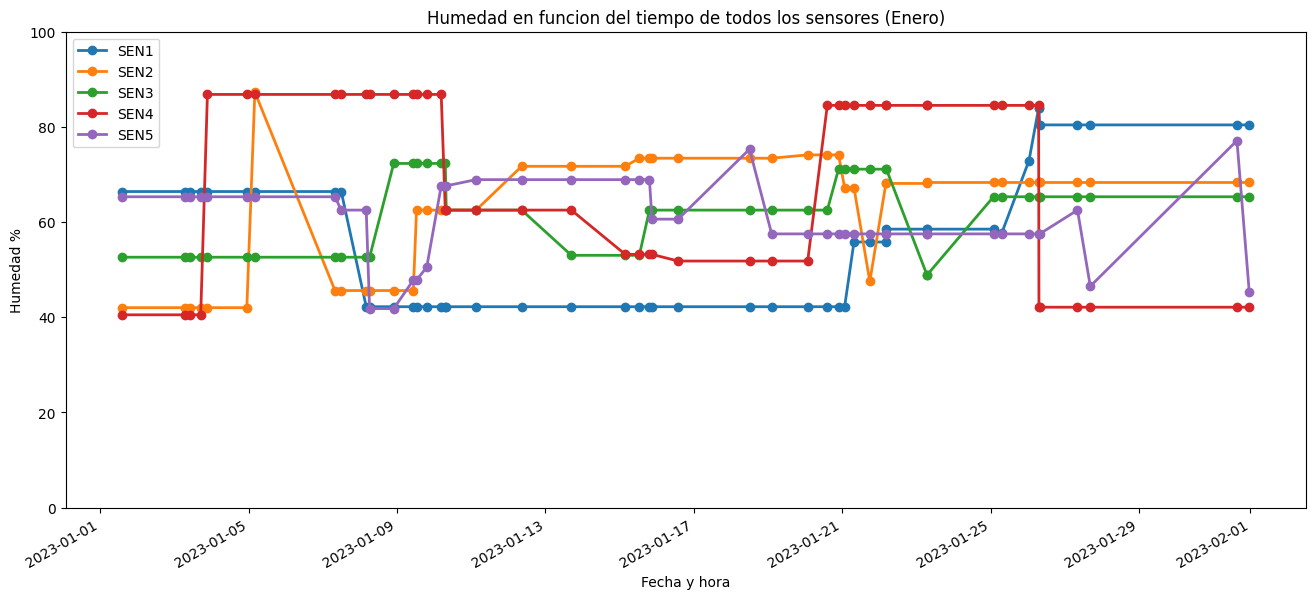

In [39]:
def line_plot_Hum_jan():
  hum_jan.plot(figsize=(16, 7), legend=True, marker='o', linewidth=2.0)
  plt.title('Humedad en funcion del tiempo de todos los sensores (Enero)')
  plt.xlabel('Fecha y hora')
  plt.ylabel('Humedad %')
  plt.ylim(0, 100)

  return plt.show()

line_plot_Hum_jan()

**Grafico de Temperatura en funcion del tiempo para todo el periodo**

In [40]:
df.set_index('fecha_hora', inplace=True)
df.head()

,id_sensor,temperatura (°C),humedad,presión,rayos_uv
fecha_hora,,,,,
2023-01-01 14:11:00,SEN1,29.8,66.4,1017.5,MODERADO
2023-01-03 06:38:00,SEN2,33.6,42.0,1004.4,BAJO
2023-01-03 09:58:00,SEN5,29.8,65.3,1007.8,MODERADO
2023-01-03 17:05:00,SEN4,29.8,40.5,1013.1,MODERADO
2023-01-03 21:25:00,SEN4,29.8,86.8,997.8,NULO


In [41]:
temp_all = pd.DataFrame(index=df.index)
temp_all.head()

""
fecha_hora
2023-01-01 14:11:00
2023-01-03 06:38:00
2023-01-03 09:58:00
2023-01-03 17:05:00
2023-01-03 21:25:00


In [42]:
temp_all['SEN1'] = df['temperatura (°C)'][df['id_sensor'].str.contains('SEN1')]
temp_all['SEN2'] = df['temperatura (°C)'][df['id_sensor'].str.contains('SEN2')]
temp_all['SEN3'] = df['temperatura (°C)'][df['id_sensor'].str.contains('SEN3')]
temp_all['SEN4'] = df['temperatura (°C)'][df['id_sensor'].str.contains('SEN4')]
temp_all['SEN5'] = df['temperatura (°C)'][df['id_sensor'].str.contains('SEN5')]
temp_all.head()

,SEN1,SEN2,SEN3,SEN4,SEN5
fecha_hora,,,,,
2023-01-01 14:11:00,29.8,NaN,NaN,NaN,NaN
2023-01-03 06:38:00,NaN,33.6,NaN,NaN,NaN
2023-01-03 09:58:00,NaN,NaN,NaN,NaN,29.8
2023-01-03 17:05:00,NaN,NaN,NaN,29.8,NaN
2023-01-03 21:25:00,NaN,NaN,NaN,29.8,NaN


In [43]:
temp_all['SEN1'] = temp_all['SEN1'].ffill()

In [44]:
temp_all['SEN2'] = temp_all['SEN2'].ffill()
temp_all['SEN2'] = temp_all['SEN2'].bfill()

In [45]:
temp_all['SEN3'] = temp_all['SEN3'].ffill()
temp_all['SEN3'] = temp_all['SEN3'].bfill()

In [46]:
temp_all['SEN4'] = temp_all['SEN4'].ffill()
temp_all['SEN4'] = temp_all['SEN4'].bfill()

In [47]:
temp_all['SEN5'] = temp_all['SEN5'].ffill()
temp_all['SEN5'] = temp_all['SEN5'].bfill()
temp_all.tail(15)

,SEN1,SEN2,SEN3,SEN4,SEN5
fecha_hora,,,,,
2023-03-02 04:33:00,29.8,29.8,29.8,29.8,29.8
2023-03-03 00:01:00,29.8,29.8,29.8,29.8,29.8
2023-03-03 14:16:00,24.0,29.8,29.8,29.8,29.8
2023-03-04 05:13:00,24.0,29.8,29.8,33.4,29.8
2023-03-05 13:06:00,24.0,32.3,29.8,33.4,29.8
2023-03-05 20:04:00,24.0,32.3,29.8,32.6,29.8
2023-03-05 21:08:00,29.8,32.3,29.8,32.6,29.8
2023-03-06 03:09:00,29.8,32.3,29.8,32.6,33.0
2023-03-07 04:10:00,29.8,32.3,29.8,29.8,33.0


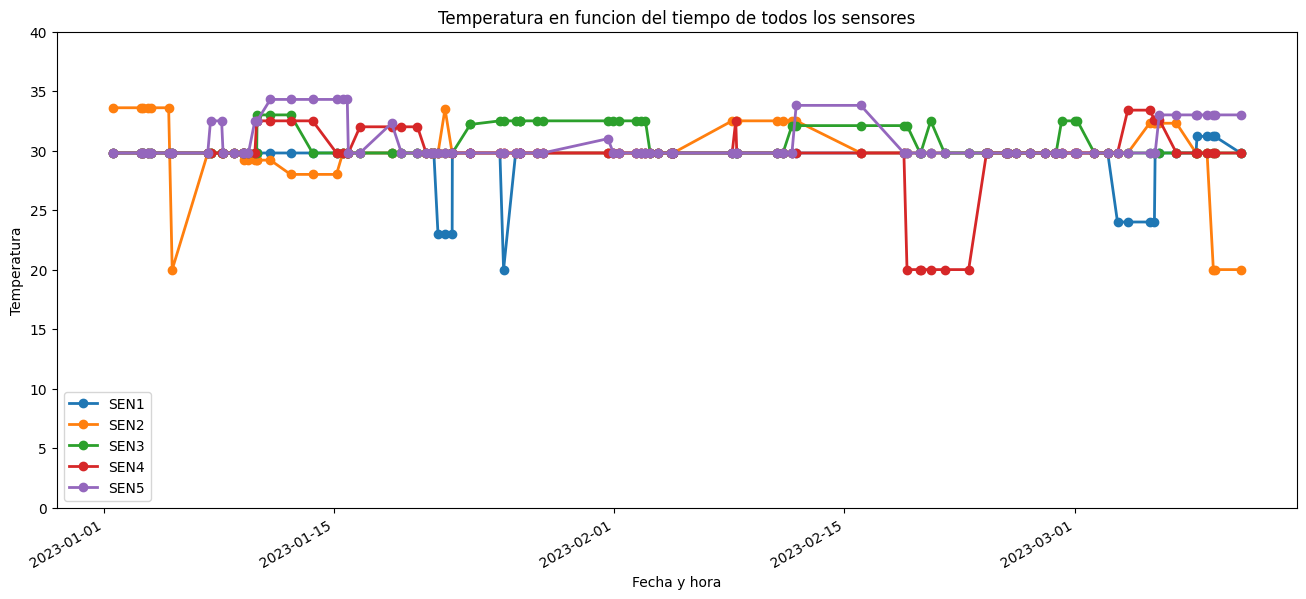

In [48]:
def draw_line_plot_temp_all():
  temp_all.plot(figsize=(16, 7), legend=True, marker='o', linewidth=2.0)
  plt.title('Temperatura en funcion del tiempo de todos los sensores')
  plt.xlabel('Fecha y hora')
  plt.ylabel('Temperatura')
  plt.ylim(0, 40)

  return plt.show()

draw_line_plot_temp_all()

**Grafico circular con la cantidad de mediciones de cada sensor**

In [49]:
df['id_sensor'].value_counts(normalize=True)

,proportion
id_sensor,
SEN5,0.24
SEN2,0.21
SEN1,0.19
SEN3,0.19
SEN4,0.17


<Axes: ylabel='count'>

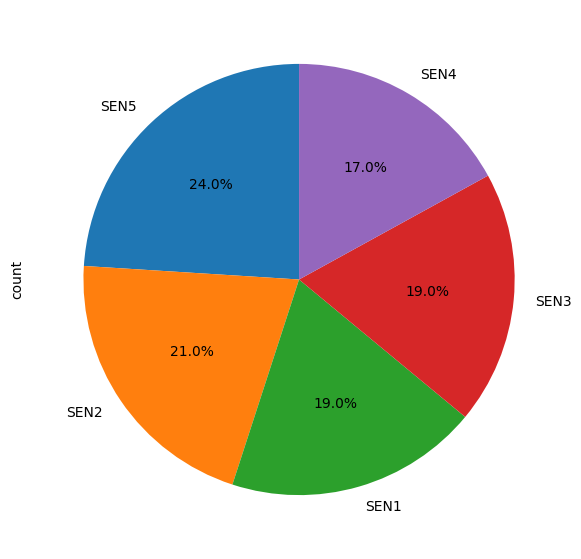

In [50]:
df['id_sensor'].value_counts().plot(kind='pie', figsize=(7, 7), autopct='%1.1f%%', startangle=90)

**Grafico circular con la cantidad de veces que se obtuvo cada medicion de la columna rayos_uv**

In [51]:
df['rayos_uv'].value_counts(normalize=True)

,proportion
rayos_uv,
NULO,0.38
MODERADO,0.24
BAJO,0.23
ALTO,0.15


<Axes: ylabel='count'>

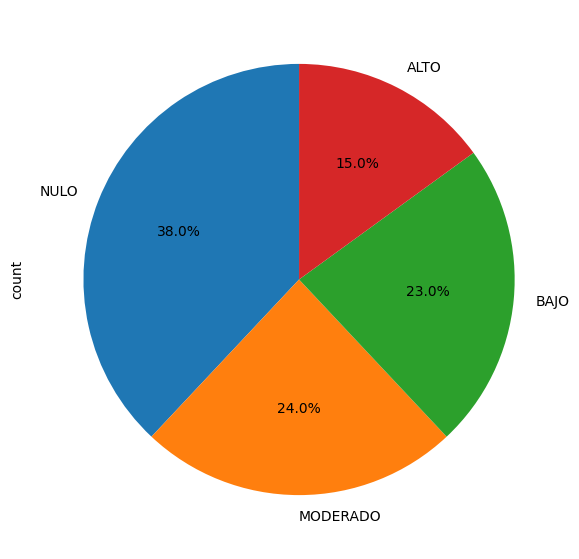

In [52]:
df['rayos_uv'].value_counts().plot(kind='pie', figsize=(7, 7), autopct='%1.1f%%', startangle=90)

**Crear un grafico que muestre la correlacion entre la temperatura y la humedad**

In [53]:
df.head()

,id_sensor,temperatura (°C),humedad,presión,rayos_uv
fecha_hora,,,,,
2023-01-01 14:11:00,SEN1,29.8,66.4,1017.5,MODERADO
2023-01-03 06:38:00,SEN2,33.6,42.0,1004.4,BAJO
2023-01-03 09:58:00,SEN5,29.8,65.3,1007.8,MODERADO
2023-01-03 17:05:00,SEN4,29.8,40.5,1013.1,MODERADO
2023-01-03 21:25:00,SEN4,29.8,86.8,997.8,NULO


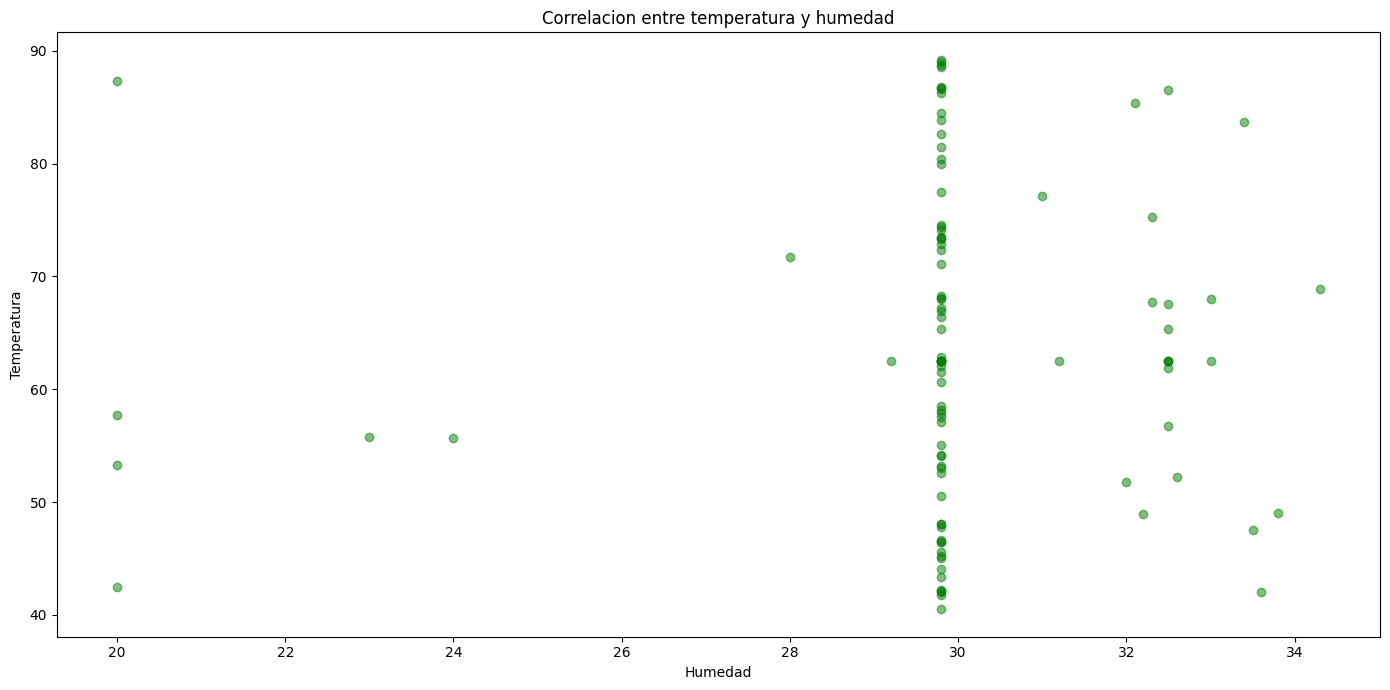

In [54]:
x = df['temperatura (°C)']
y = df['humedad']

plt.figure(figsize=(14, 7))
plt.scatter(x, y, c='g', alpha=0.5)

plt.title('Correlacion entre temperatura y humedad')
plt.xlabel('Humedad')
plt.ylabel('Temperatura')

plt.tight_layout()
plt.show()

In [55]:
correlation = df['temperatura (°C)'].corr(df['humedad'])
round(correlation, 2)

np.float64(0.05)

**Crear un grafico que muestre la correlacion entre la temperatura y la presion**

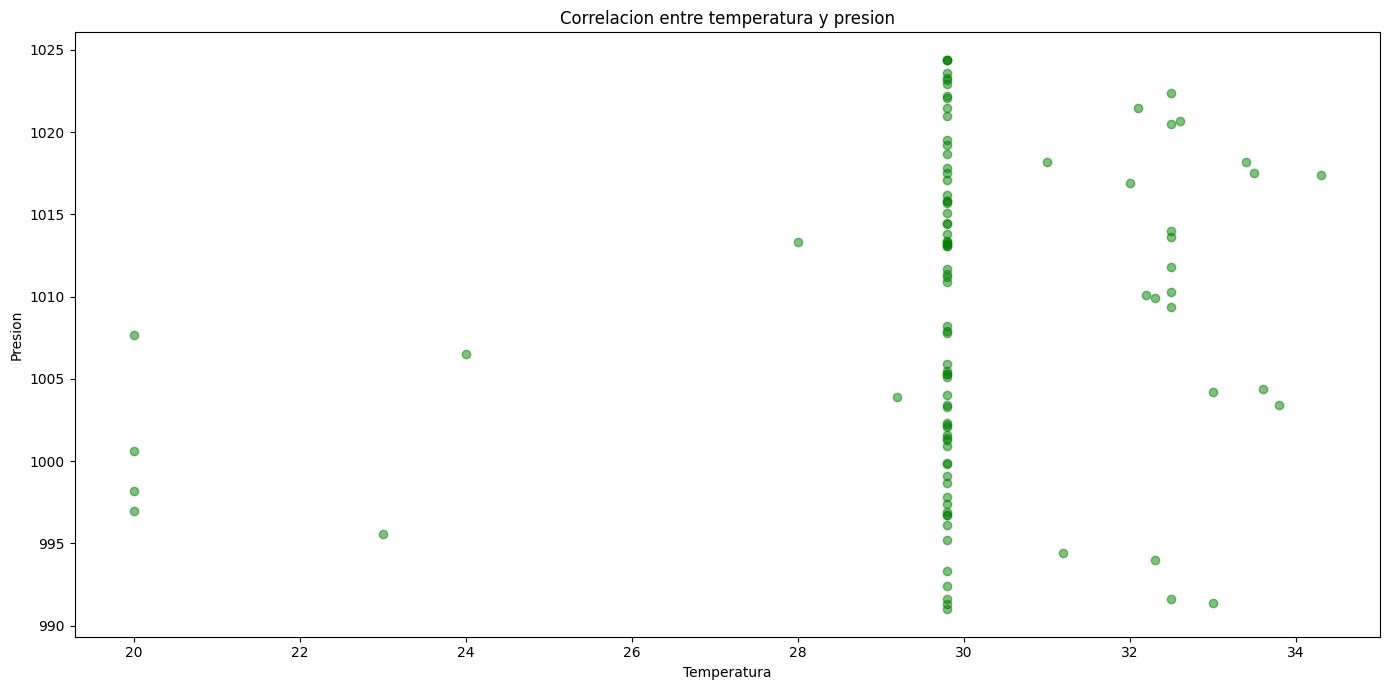

In [56]:
x = df['temperatura (°C)']
y = df['presión']

plt.figure(figsize=(14, 7))
plt.scatter(x, y, c='g', alpha=0.5)

plt.title('Correlacion entre temperatura y presion')
plt.xlabel('Temperatura')
plt.ylabel('Presion')

plt.tight_layout()
plt.show()

In [57]:
correlation = df['temperatura (°C)'].corr(df['presión'])
round(correlation, 2)

np.float64(0.2)